# K-Means Baseline Experiment
**Project:** Booking complexity & behavior dynamics  
**Milestone 2** — Baseline modelling evidence (Section 5)

Follows the experimental protocol from Lab4 (ANSup26):
- `n_init=1` per call, loop controlled externally
- seed formula: `seed = 100 * K + run`
- M = 10 runs per (K, init_method) pair
- K values: 2–8
- Both `random` and `k-means++` initialisation
- PCA pre-processing before clustering (85% variance)
- Subsampling stability: 3 independent subsamples
- All results logged to `experiments.csv`

## Setup

In [1]:
import os
# Force single-threaded numerical libs for reproducible runtimes (Lab4 pattern)
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import date
from sklearn.decomposition import PCA
from IPython.display import display

from src.preprocessing import preprocess_data, NUMERICAL_FEATURES
from src.clustering import fit_predict, fit_kmeans_once
from src.evaluation import evaluate_clustering, metric_info
from src.utils import load_subsample_indices, log_experiment

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# Colour palette from Lab4
SLIDE_PALETTE = [
    "#4C6FE7", "#E3B340", "#4FA64F", "#E45756",
    "#8E63C7", "#D99AD7", "#8C6D31", "#7F7F7F",
]

DATA_PATH       = "../data/hotel_bookings_course_release_v1.csv"
INDICES_PATH    = "../data/subsample_indices_v1_n30000_seed12345.txt"
EXPERIMENTS_CSV = "../experiments.csv"

## 1. Load data and preprocess

In [2]:
df_full = pd.read_csv(DATA_PATH)
indices = load_subsample_indices(INDICES_PATH)
df = df_full.iloc[indices].reset_index(drop=True)
print(f"Subsample shape: {df.shape}")

# Representation: all features, winsorization (Lab2 Q9) + StandardScaler + PCA 85%
REPRESENTATION_ID = "rep_full_winsor_std_pca85"

X_raw, feature_names_raw, scaler, ohe, artifacts = preprocess_data(
    df, feature_set="no_value_block", scaler="standard"
)

# PCA before clustering — reduces noise from low-variance OHE dimensions
# Keep components that explain 85% of variance, following Lab4 PCA usage
pca_pre = PCA(n_components=0.85, random_state=0)
X = pca_pre.fit_transform(X_raw)
artifacts["pca_pre"] = pca_pre

n, d = X.shape
n_components = d

summary_df = pd.DataFrame({
    "quantity": ["n samples", "d features (raw)", "d features (after PCA)", 
                 "PCA variance explained", "representation_id",
                 "candidate K values", "runs per K and method"],
    "value": [len(df), X_raw.shape[1], d,
              f"{pca_pre.explained_variance_ratio_.sum():.1%}",
              REPRESENTATION_ID, "2, 3, 4, 5, 6, 7, 8", 10],
})
display(summary_df)

Subsample shape: (30000, 32)


,quantity,value
0,n samples,30000
1,d features (raw),34
2,d features (after PCA),9
3,PCA variance explained,86.5%
4,representation_id,rep_full_winsor_std_pca85
5,candidate K values,"2, 3, 4, 5, 6, 7, 8"
6,runs per K and method,10


## 2. PCA projection for visualisation

The clustering space already uses PCA (85% variance). Here we project further to 2D for visualisation — mirrors Lab4.

In [3]:
# 2D projection of the already-PCA-reduced space for visualisation
pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X)

pca3 = PCA(n_components=3)
X_pca3 = pca3.fit_transform(X)

proj_df = pd.DataFrame({
    "component": ["PC1", "PC2", "PC3"],
    "explained_variance_ratio (of PCA space)": pca3.explained_variance_ratio_,
    "cumulative": np.cumsum(pca3.explained_variance_ratio_),
})
print(f"Clustering space: {n_components} PCA components (85% of raw variance)")
display(proj_df.round(3))

Clustering space: 9 PCA components (85% of raw variance)


,component,explained_variance_ratio (of PCA space),cumulative
0,PC1,0.182,0.182
1,PC2,0.152,0.334
2,PC3,0.136,0.470


## 3. Plotting helpers

Direct adaptation of the Lab4 plotting functions.

In [4]:
def plot_partition_2d(ax, coords, labels, centers, title):
    """2-D PCA scatter coloured by cluster — mirrors Lab4 plot_partition_2d."""
    K = len(np.unique(labels))
    for k in range(K):
        mask = labels == k
        ax.scatter(
            coords[mask, 0], coords[mask, 1],
            s=10,
            c=SLIDE_PALETTE[k % len(SLIDE_PALETTE)],
            alpha=0.6,
            edgecolor="white",
            linewidth=0.2,
        )
    centers_2d = pca2.transform(centers)
    ax.scatter(
        centers_2d[:, 0], centers_2d[:, 1],
        c="black", s=110, marker="X", linewidth=0.8, zorder=5,
    )
    ax.set_title(title)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

## 4. Quick visual — k-means++ for K ∈ {2, 3, 4, 5}

Single run per K, just to see the partitions before the full protocol — mirrors Lab4 Cell 18.

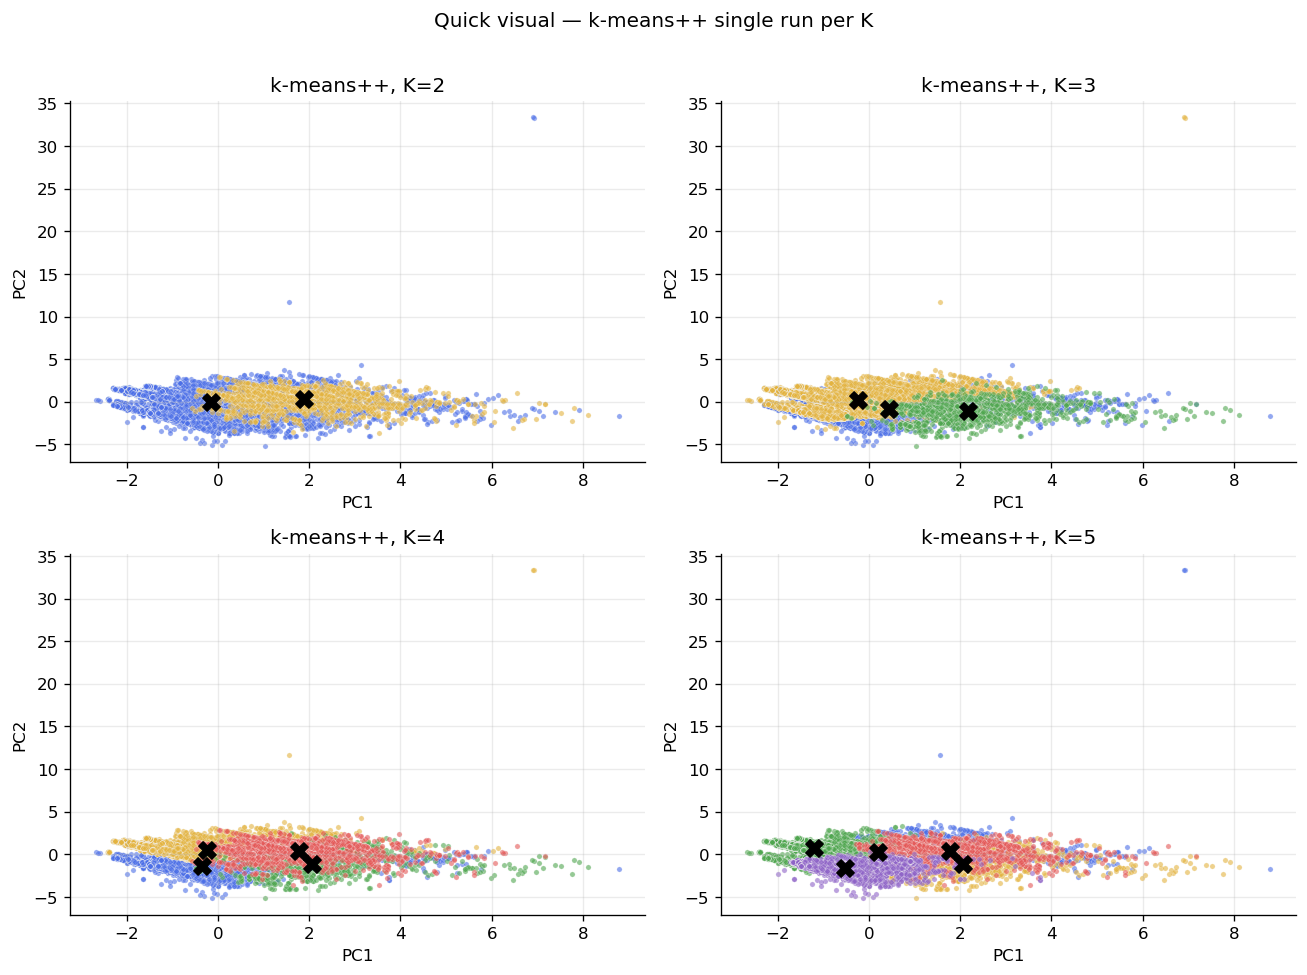

In [5]:
K_demo   = [2, 3, 4, 5]
seed_demo = 7

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, K in zip(axes.ravel(), K_demo):
    _, labels_demo, centers_demo = fit_kmeans_once(
        X, K, init_method="k-means++", seed=seed_demo + K
    )
    plot_partition_2d(ax, X_pca2, labels_demo, centers_demo, title=f"k-means++, K={K}")
plt.suptitle("Quick visual — k-means++ single run per K", y=1.01)
plt.tight_layout()
plt.show()

## 5. Experimental protocol — K-Means

Mirrors Lab4 Cell 25 (`run_experimental_protocol`):

- K ∈ {2, 3, 4, 5, 6, 7, 8}
- M = 10 runs per (K, init_method)
- `seed = 100 × K + run` (same formula as Lab4)
- Both `random` and `k-means++` initialisation
- Every run logged to `experiments.csv`

In [6]:
K_VALUES     = list(range(2, 9))    # 2 … 8
M            = 10                   # minimum 10 runs — Milestone 2 spec
INIT_METHODS = ["random", "k-means++"]

all_rows = []

for init_method in INIT_METHODS:
    for K in K_VALUES:
        for run in range(1, M + 1):
            seed = 100 * K + run    # Lab4 seed formula

            labels, model, runtime = fit_predict(
                X, K, seed=seed, algorithm="kmeans", init_method=init_method
            )
            metrics = evaluate_clustering(X, labels, runtime=runtime)

            row = {
                "date":              date.today().isoformat(),
                "representation_id": REPRESENTATION_ID,
                "method":            "kmeans",
                "init":              init_method,
                "K":                 K,
                "run":               run,
                "seed":              seed,
                "sample_rule":       f"subsample_n{n}_seed12345",
                "inertia":           model.inertia_,
                "n_iter":            model.n_iter_,
                **metrics,
            }
            all_rows.append(row)
            log_experiment(row, filepath=EXPERIMENTS_CSV)

all_runs = pd.DataFrame(all_rows)
print(f"Total runs logged: {len(all_runs)}")
display(all_runs.head(6))

Total runs logged: 140


,date,representation_id,method,init,K,run,seed,sample_rule,inertia,n_iter,silhouette,calinski_harabasz,davies_bouldin,runtime_s
0,2026-04-29,rep_full_winsor_std_pca85,kmeans,random,2,1,201,subsample_n30000_seed12345,210310.473765,9,0.197848,4131.457829,2.303198,0.029256
1,2026-04-29,rep_full_winsor_std_pca85,kmeans,random,2,2,202,subsample_n30000_seed12345,207911.635064,3,0.435102,4525.202332,1.149346,0.010783
2,2026-04-29,rep_full_winsor_std_pca85,kmeans,random,2,3,203,subsample_n30000_seed12345,210860.317734,8,0.311279,4042.440324,2.386930,0.015292
3,2026-04-29,rep_full_winsor_std_pca85,kmeans,random,2,4,204,subsample_n30000_seed12345,214773.230677,11,0.243114,3422.333741,2.532792,0.017754
4,2026-04-29,rep_full_winsor_std_pca85,kmeans,random,2,5,205,subsample_n30000_seed12345,214360.269698,20,0.112129,3486.656811,2.166848,0.025570
5,2026-04-29,rep_full_winsor_std_pca85,kmeans,random,2,6,206,subsample_n30000_seed12345,214360.258523,22,0.112141,3486.660601,2.167221,0.025593


## 6. Score variability across runs

Mean and std of each metric per (init, K) — mirrors Lab4 Cell 25 `score_variability`.

In [7]:
score_variability = (
    all_runs
    .groupby(["init", "K"])[["silhouette", "calinski_harabasz", "davies_bouldin", "inertia"]]
    .agg(["mean", "std"])
    .round(4)
)
display(score_variability)

silhouette         calinski_harabasz            davies_bouldin  \
                  mean     std              mean        std           mean   
init      K                                                                  
k-means++ 2     0.4174  0.2324         4160.4918   319.3940         1.5684   
          3     0.1867  0.0363         4030.8445   390.6611         1.8590   
          4     0.2081  0.0262         4605.5942   369.1643         1.5804   
          5     0.2146  0.0166         5499.8824   451.4492         1.3699   
          6     0.2401  0.0145         5969.5777   717.5456         1.2478   
          7     0.2571  0.0165         6615.6931   910.3703         1.1772   
          8     0.2648  0.0211         6781.1767   951.7591         1.1697   
random    2     0.2314  0.1155         3882.7648   382.2259         2.0860   
          3     0.1813  0.0575         3995.0801   354.3669         1.9218   
          4     0.1902  0.0151         3960.4228   322.3223         1.7426   
          5     0.2110  0.0154         4490.2758   630.5034         1.5619   
          6     0.2248  0.0191         4775.5631   709.9120         1.4003   
          7     0.2519  0.0247         5121.0994   902.1517         1.3101   
          8     0.2545  0.0274         5566.2626  1267.1303         1.2589   

                         inertia              
                std         mean         std  
init      K                                   
k-means++ 2  0.8980  210148.3593   1985.1933  
          3  0.1289  188662.6971   3849.3092  
          4  0.1012  163910.5635   4089.1550  
          5  0.0717  138190.9342   4990.1881  
          6  0.0994  120332.7818   7477.5134  
          7  0.1209  103642.5889   9379.1520  
          8  0.1358   93304.5304   8535.7727  
random    2  0.4534  211878.4163   2388.9935  
          3  0.1868  189005.2664   3480.7065  
          4  0.1318  171471.4235   3943.5784  
          5  0.1467  150023.3781   7708.0524  
          6  0.1085  133773.9762   9352.9414  
          7  0.1530  119102.3180  11365.8702  
          8  0.1408  105527.2220  12648.1847

## 7. Best run per K and metric curves

Mirrors Lab4 Cells 26–27: for each (init, metric) pick the best run per K, then plot curves.

In [8]:
def best_run_per_K(df_runs, metric_name):
    direction = metric_info[metric_name]["direction"]
    if direction == "max":
        idx = df_runs.groupby("K")[metric_name].idxmax()
    else:
        idx = df_runs.groupby("K")[metric_name].idxmin()
    return df_runs.loc[idx].sort_values("K").reset_index(drop=True)


curve_rows      = []
best_partitions = {}   # (init_method, metric_name) -> best row
summary_rows    = []

for init_method in INIT_METHODS:
    subset = all_runs[all_runs["init"] == init_method].copy()
    for metric_name, info in metric_info.items():
        best_k_table = best_run_per_K(subset, metric_name)

        for _, row in best_k_table.iterrows():
            curve_rows.append({
                "init":       init_method,
                "metric":     metric_name,
                "K":          int(row["K"]),
                "best_score": float(row[metric_name]),
            })

        # best overall K for this (init, metric)
        if info["direction"] == "max":
            best_row = best_k_table.loc[best_k_table[metric_name].idxmax()]
        else:
            best_row = best_k_table.loc[best_k_table[metric_name].idxmin()]

        best_partitions[(init_method, metric_name)] = best_row
        summary_rows.append({
            "init":       init_method,
            "metric":     info["label"],
            "direction":  info["direction"],
            "K_best":     int(best_row["K"]),
            "best_score": float(best_row[metric_name]),
            "seed":       int(best_row["seed"]),
        })

curve_df     = pd.DataFrame(curve_rows)
best_summary = pd.DataFrame(summary_rows)
display(best_summary.round(4))

,init,metric,direction,K_best,best_score,seed
0,random,Silhouette,max,2,0.4351,202
1,random,Calinski–Harabasz,max,8,7683.1491,809
2,random,Davies–Bouldin,min,8,1.0323,801
3,k-means++,Silhouette,max,2,0.7328,201
4,k-means++,Calinski–Harabasz,max,8,7683.1491,803
5,k-means++,Davies–Bouldin,min,2,0.4422,201


## 8. Metric curves plot

Mirrors Lab4 Cell 27.

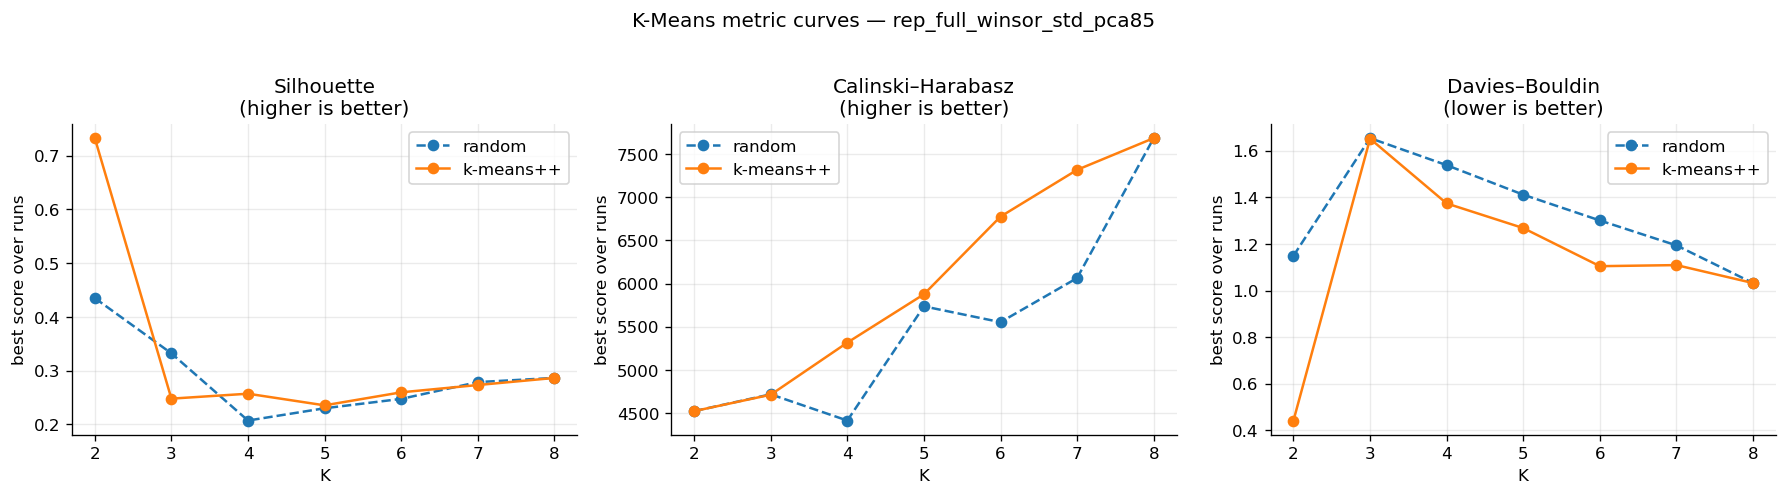

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, metric_name in zip(axes, metric_info):
    info = metric_info[metric_name]
    for init_method, line_style in [("random", "--"), ("k-means++", "-")]:
        sub = curve_df[
            (curve_df["init"] == init_method) & (curve_df["metric"] == metric_name)
        ]
        ax.plot(sub["K"], sub["best_score"], marker="o", linestyle=line_style, label=init_method)
    better = "higher is better" if info["direction"] == "max" else "lower is better"
    ax.set_title(f"{info['label']}\n({better})")
    ax.set_xlabel("K")
    ax.set_xticks(K_VALUES)
    ax.set_ylabel("best score over runs")
    ax.legend(frameon=True)

plt.suptitle(f"K-Means metric curves — {REPRESENTATION_ID}", y=1.02)
plt.tight_layout()
plt.show()

## 9. Inertia (elbow) curve

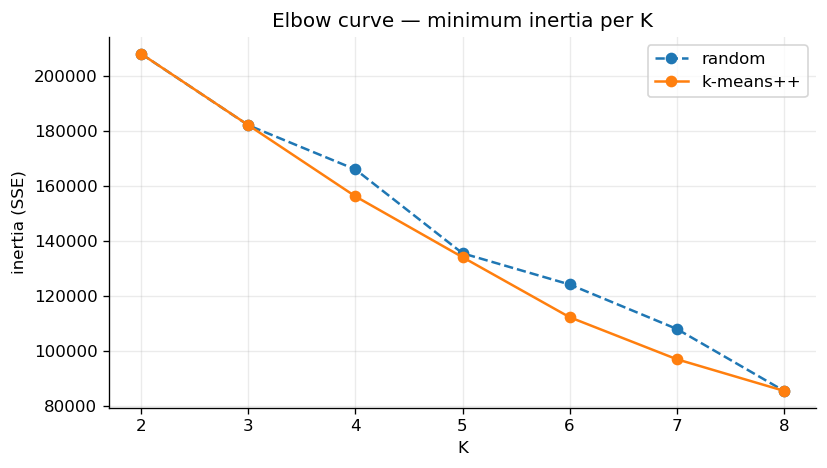

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
for init_method, line_style in [("random", "--"), ("k-means++", "-")]:
    sub = all_runs[all_runs["init"] == init_method].groupby("K")["inertia"].min()
    ax.plot(sub.index, sub.values, marker="o", linestyle=line_style, label=init_method)
ax.set_title("Elbow curve — minimum inertia per K")
ax.set_xlabel("K")
ax.set_xticks(K_VALUES)
ax.set_ylabel("inertia (SSE)")
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

## 10. Best partitions — 2D PCA visualisation

Mirrors Lab4 Cell 32: best partition per (init, metric) shown in PCA space.

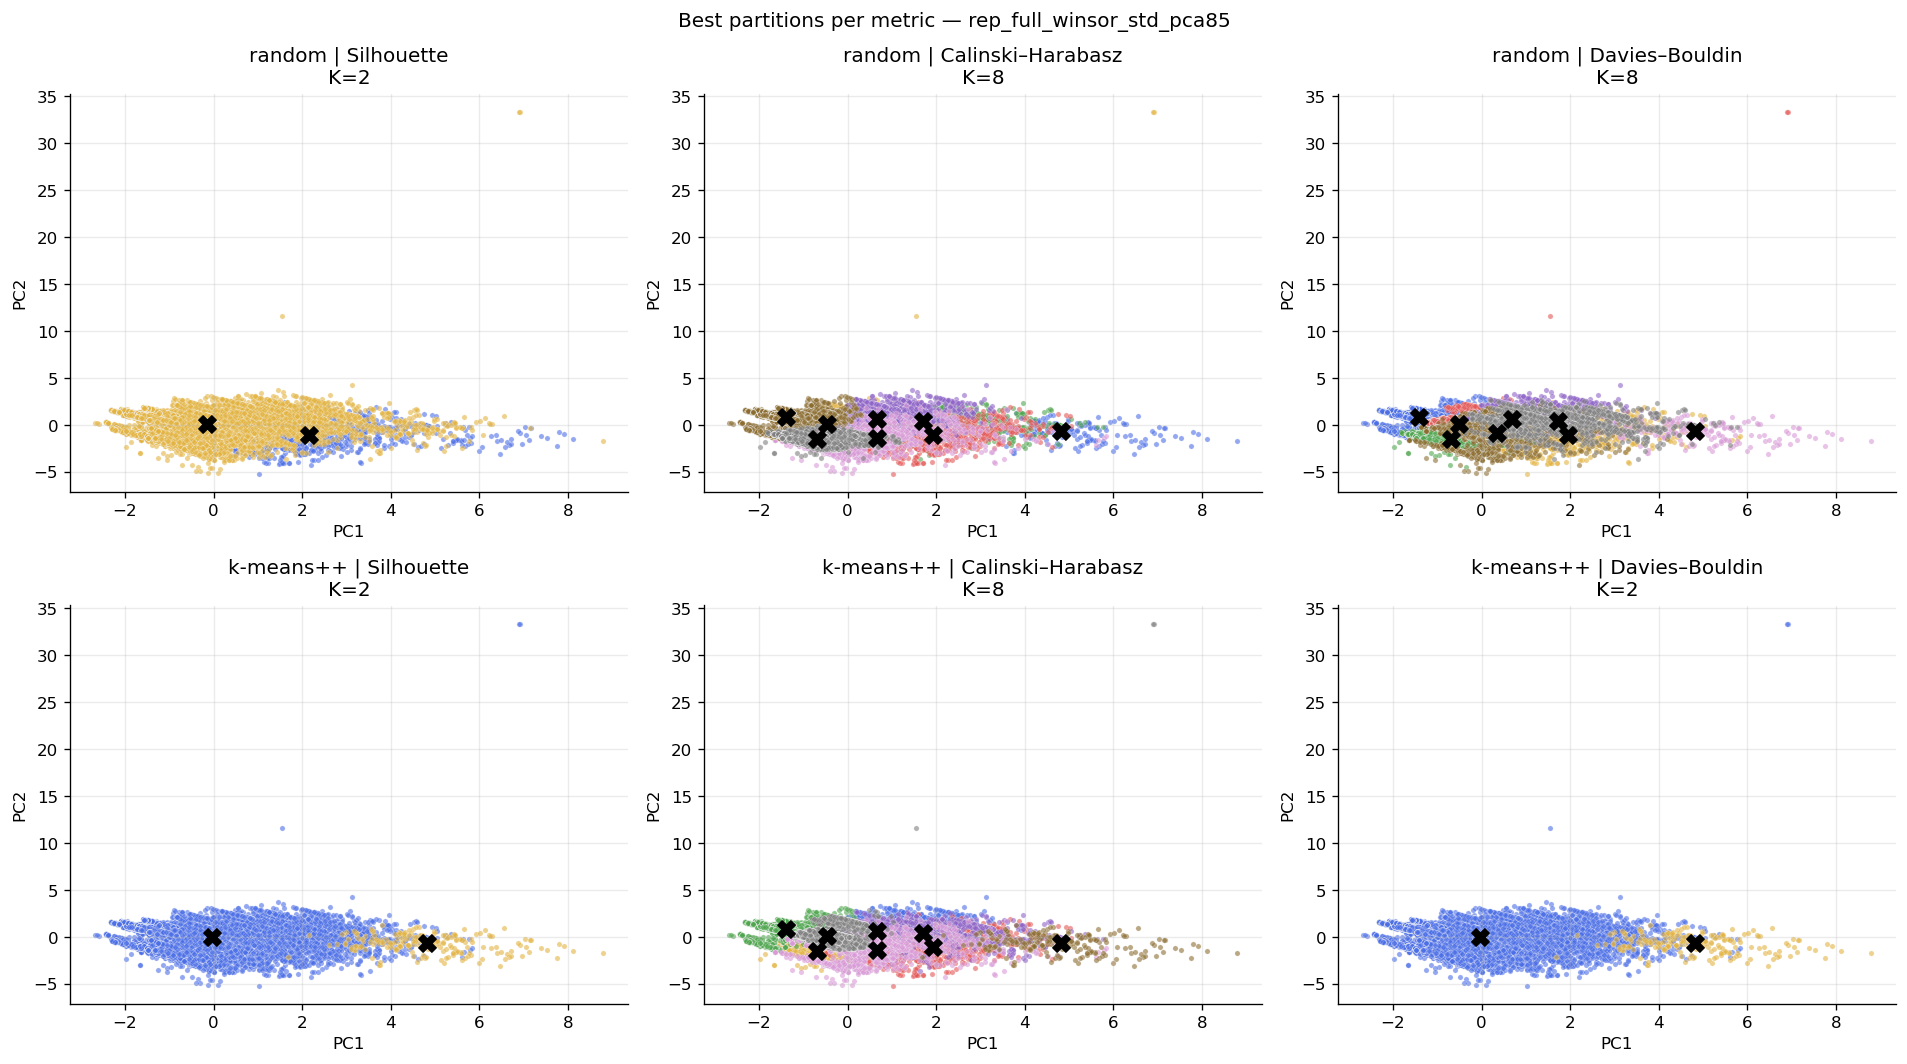

In [11]:
metric_order  = list(metric_info.keys())
metric_titles = {k: v["label"] for k, v in metric_info.items()}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for i, init_method in enumerate(INIT_METHODS):
    for j, metric_name in enumerate(metric_order):
        best_row = best_partitions[(init_method, metric_name)]
        K_best   = int(best_row["K"])
        seed_best = int(best_row["seed"])
        # re-fit to recover labels + centers for plotting
        _, labels_plot, centers_plot = fit_kmeans_once(
            X, K_best, init_method=init_method, seed=seed_best
        )
        plot_partition_2d(
            axes[i, j], X_pca2, labels_plot, centers_plot,
            title=f"{init_method} | {metric_titles[metric_name]}\nK={K_best}",
        )
plt.suptitle(f"Best partitions per metric — {REPRESENTATION_ID}")
plt.tight_layout()
plt.show()

## 11. Cluster profiles — K=3 (best silhouette), K=6 and K=7 (best Davies-Bouldin)

Profile computed on original (unscaled) values — gives interpretable means per cluster.
A GLOBAL row is appended for reference.
K=3 is the best by silhouette; K=6 and K=7 are the most promising for RQ1 interpretation.

In [12]:
def show_profile(K_target, init_method, metric_name):
    """Re-fit the best partition for a given K and show the cluster profile."""
    best_row  = best_run_per_K(
        all_runs[all_runs["init"] == init_method], metric_name
    )
    row = best_row[best_row["K"] == K_target].iloc[0]
    seed_best = int(row["seed"])

    _, labels, _ = fit_kmeans_once(X, K_target, init_method=init_method, seed=seed_best)

    num_cols   = [c for c in NUMERICAL_FEATURES if c in df.columns]
    profile_df = df[num_cols].copy()
    profile_df["cluster"] = labels

    profile = profile_df.groupby("cluster")[num_cols].mean().round(2)
    profile.loc["GLOBAL"] = df[num_cols].mean().round(2)

    sizes = pd.Series(labels).value_counts().sort_index().rename("n")

    print(f"\n{'='*60}")
    print(f"Cluster profile — {init_method}, K={K_target}, seed={seed_best} (best {metric_name})")
    print(f"{'='*60}")
    display(profile)
    print("Cluster sizes:")
    display(sizes)


# K=3 — best by silhouette (interpretable baseline)
show_profile(3, "k-means++", "silhouette")

# K=6 — best Davies-Bouldin candidate
show_profile(6, "k-means++", "davies_bouldin")

# K=7 — best Davies-Bouldin candidate
show_profile(7, "k-means++", "davies_bouldin")



Cluster profile — k-means++, K=3, seed=301 (best silhouette)


,lead_time,booking_changes,days_in_waiting_list,adults,children,babies,previous_cancellations,previous_bookings_not_canceled,adr,total_of_special_requests,required_car_parking_spaces,is_repeated_guest
cluster,,,,,,,,,,,,
0,88.62,0.33,0.07,1.95,1.44,0.02,0.01,0.02,155.90,0.90,0.12,0.01
1,118.37,0.06,2.68,2.07,0.00,0.00,0.11,0.02,101.48,0.58,0.05,0.01
2,67.21,0.65,1.72,1.23,0.00,0.02,0.06,0.49,86.99,0.40,0.08,0.09
GLOBAL,103.80,0.22,2.26,1.85,0.10,0.01,0.09,0.14,101.83,0.56,0.06,0.03


Cluster sizes:


0     2138
1    20559
2     7303
Name: n, dtype: int64


Cluster profile — k-means++, K=6, seed=608 (best davies_bouldin)


...

0    17866
1     7151
2      219
3     1893
4     1165
5     1706
Name: n, dtype: int64


Cluster profile — k-means++, K=7, seed=707 (best davies_bouldin)


,lead_time,booking_changes,days_in_waiting_list,adults,children,babies,previous_cancellations,previous_bookings_not_canceled,adr,total_of_special_requests,required_car_parking_spaces,is_repeated_guest
cluster,,,,,,,,,,,,
0,122.15,1.68,1.87,1.86,0.02,0.00,0.01,0.08,100.54,0.49,0.01,0.03
1,54.04,0.16,2.01,1.00,0.00,0.00,0.08,0.52,82.39,0.22,0.00,0.10
2,145.44,0.00,4.48,2.04,0.00,0.00,0.19,0.02,94.00,0.08,0.00,0.01
3,75.74,0.04,0.01,2.05,0.00,0.00,0.02,0.05,110.94,1.45,0.00,0.02
4,78.07,0.87,0.00,1.99,0.20,1.00,0.01,0.01,117.20,1.57,0.21,0.01
5,88.96,0.25,0.06,1.93,1.49,0.00,0.01,0.02,156.70,0.86,0.06,0.01
6,52.55,0.33,0.11,1.88,0.07,0.00,0.03,0.54,108.43,0.82,1.00,0.09
GLOBAL,103.80,0.22,2.26,1.85,0.10,0.01,0.09,0.14,101.83,0.56,0.06,0.03


Cluster sizes:


0     2595
1     4490
2    11953
3     7100
4      219
5     1909
6     1734
Name: n, dtype: int64

## 12. Convergence — number of iterations per (init, K)

Mirrors Lab4 Cell 22: checks convergence speed of `random` vs `k-means++`.

,init,K,mean_iterations,median_iterations,std_iterations,min_iterations,max_iterations
0,k-means++,2,6.3,6.0,4.30,2,13
1,k-means++,3,13.5,10.5,9.22,7,39
2,k-means++,4,16.3,13.5,11.16,6,41
3,k-means++,5,13.0,10.5,6.55,8,30
4,k-means++,6,10.1,9.0,3.51,6,19
5,k-means++,7,11.6,12.0,2.17,8,15
6,k-means++,8,11.8,11.0,3.12,8,18
7,random,2,12.0,11.5,6.68,3,22
8,random,3,10.7,10.5,3.89,6,18
9,random,4,14.5,14.0,4.90,9,25


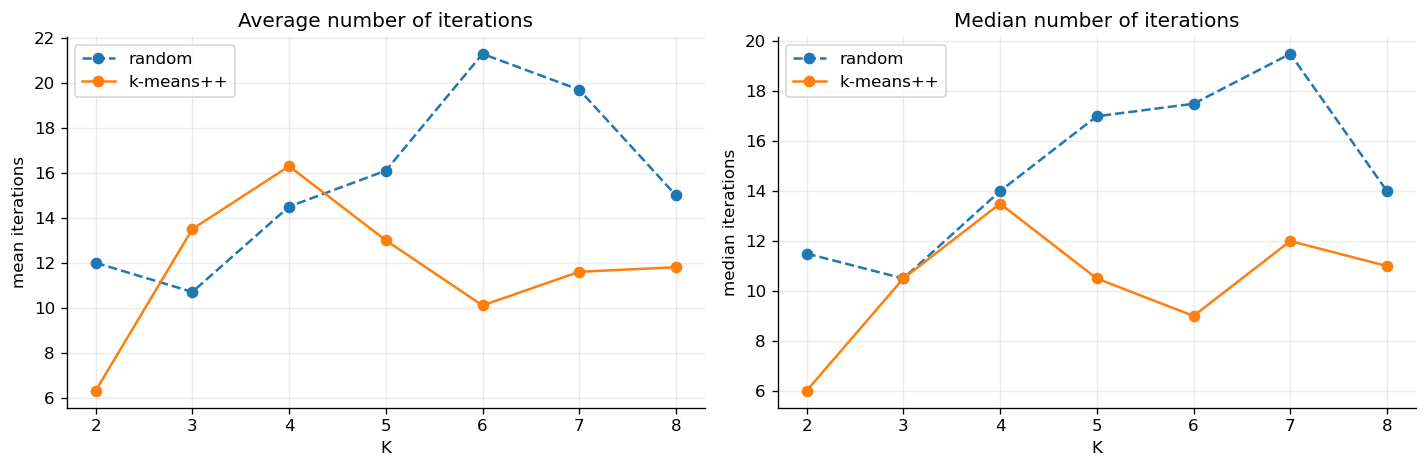

In [13]:
conv_summary = (
    all_runs
    .groupby(["init", "K"])
    .agg(
        mean_iterations=("n_iter", "mean"),
        median_iterations=("n_iter", "median"),
        std_iterations=("n_iter", "std"),
        min_iterations=("n_iter", "min"),
        max_iterations=("n_iter", "max"),
    )
    .reset_index()
)
display(conv_summary.round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, stat_name, title in [
    (axes[0], "mean_iterations",   "Average number of iterations"),
    (axes[1], "median_iterations", "Median number of iterations"),
]:
    for init_method, line_style in [("random", "--"), ("k-means++", "-")]:
        sub = conv_summary[conv_summary["init"] == init_method]
        ax.plot(sub["K"], sub[stat_name], marker="o", linestyle=line_style, label=init_method)
    ax.set_title(title)
    ax.set_xlabel("K")
    ax.set_ylabel(stat_name.replace("_", " "))
    ax.set_xticks(K_VALUES)
    ax.legend(frameon=True)
plt.tight_layout()
plt.show()

## 13. Runtime summary

In [14]:
runtime_summary = (
    all_runs
    .groupby(["init", "K"])["runtime_s"]
    .agg(["mean", "min", "max"])
    .round(3)
)
display(runtime_summary)

mean    min    max
init      K                     
k-means++ 2  0.013  0.009  0.018
          3  0.020  0.014  0.042
          4  0.023  0.015  0.044
          5  0.023  0.018  0.039
          6  0.022  0.017  0.032
          7  0.025  0.021  0.028
          8  0.025  0.022  0.031
random    2  0.019  0.010  0.029
          3  0.018  0.013  0.024
          4  0.021  0.016  0.033
          5  0.027  0.018  0.053
          6  0.030  0.018  0.068
          7  0.030  0.019  0.046
          8  0.024  0.017  0.029

## 14. Subsampling stability

Tests whether the best partition is stable across different subsamples of the data.
Mirrors the Lab4 robustness protocol: rerun on independent subsamples, 
compute ARI between the best k-means++ partition on each subsample.

In [15]:
from sklearn.metrics import adjusted_rand_score

# Three independent subsamples — different random seeds, same size
# Follows Lab4 subsampling strategy
SUBSAMPLE_SIZE  = 5000   # smaller for speed; increase for final results
SUBSAMPLE_SEEDS = [42, 123, 999]
K_STABILITY     = 7      # use the most promising K from the analysis above

subsample_labels = []
subsample_rows   = []

for ss_seed in SUBSAMPLE_SEEDS:
    rng = np.random.default_rng(ss_seed)
    ss_idx = rng.choice(len(df_full), size=SUBSAMPLE_SIZE, replace=False)
    df_ss  = df_full.iloc[ss_idx].reset_index(drop=True)

    # Preprocess independently — each subsample fits its own scaler
    X_ss_raw, _, scaler_ss, ohe_ss, artifacts_ss = preprocess_data(
        df_ss, feature_set="no_value_block", scaler="standard"
    )
    pca_ss = PCA(n_components=0.85, random_state=0)
    X_ss   = pca_ss.fit_transform(X_ss_raw)

    # Best run: k-means++ with 10 seeds, pick best silhouette
    best_sil, best_labels = -1, None
    for run in range(1, 11):
        seed = 100 * K_STABILITY + run
        labels_ss, _, rt = fit_predict(
            X_ss, K_STABILITY, seed=seed, algorithm="kmeans", init_method="k-means++"
        )
        metrics_ss = evaluate_clustering(X_ss, labels_ss, runtime=rt)
        if metrics_ss["silhouette"] > best_sil:
            best_sil    = metrics_ss["silhouette"]
            best_labels = labels_ss
        subsample_rows.append({
            "subsample_seed": ss_seed,
            "subsample_size": SUBSAMPLE_SIZE,
            "K": K_STABILITY,
            "run": run,
            "seed": seed,
            **metrics_ss,
        })

    subsample_labels.append(best_labels)

ss_df = pd.DataFrame(subsample_rows)

# ARI between each pair of subsamples — measures label stability
# Note: ARI on different subsamples requires overlapping indices;
# here we compare same-size random samples so ARI is approximate
ari_pairs = []
for i in range(len(SUBSAMPLE_SEEDS)):
    for j in range(i + 1, len(SUBSAMPLE_SEEDS)):
        min_len = min(len(subsample_labels[i]), len(subsample_labels[j]))
        ari = adjusted_rand_score(
            subsample_labels[i][:min_len],
            subsample_labels[j][:min_len]
        )
        ari_pairs.append({
            "subsample_A": SUBSAMPLE_SEEDS[i],
            "subsample_B": SUBSAMPLE_SEEDS[j],
            "ARI": round(ari, 4),
        })

print(f"Subsampling stability — K={K_STABILITY}, k-means++")
display(pd.DataFrame(ari_pairs))

print("\nBest silhouette per subsample:")
display(
    ss_df.groupby("subsample_seed")["silhouette"]
    .max()
    .reset_index()
    .round(4)
)

Subsampling stability — K=7, k-means++


,subsample_A,subsample_B,ARI
0,42,123,-0.0007
1,42,999,-0.0018
2,123,999,0.0025



Best silhouette per subsample:


,subsample_seed,silhouette
0,42,0.2880
1,123,0.2715
2,999,0.2670
